# Reto de la Semanan 6: Comparación de Descenso de Gradiente y Descenso de Gradiente Estocastico 



Este cuaderno implementa la solución al problema de comparación de los algoritmos de descenso de gradiente y descenso de gradiente estocastico

In [2]:
#  Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# importamos los datos
ruta_archivo = 'BreastCancer.csv'
data = pd.read_csv(ruta_archivo)

In [4]:
# Extraemos los valores de los datos en la matriz X
X = data[['radius_mean', 'smoothness_mean']].values

# Extraemos la variable objetivo
t = data['pronostic'].values

Z = np.hstack((X, np.ones((X.shape[0], 1))))

m = Z.shape[0] # # entrenamiento
n = Z.shape[1] # # caracteristicas

print(f"\nDimensión de Z (características + intercepto): {Z.shape}")
print(f"Dimensión de t (objetivo): {t.shape}")


Dimensión de Z (características + intercepto): (469, 3)
Dimensión de t (objetivo): (469,)


In [5]:
def sigmoid(v):
    """
    funcion sigmoide.
    """
    return 1 / (1 + np.exp(-v))

In [6]:
def loss_function(w, Z, t):
    """
    funcion de perdida de la regresion logistica
    """
    y = sigmoid(Z @ w) 
    epsilon = 1e-15 
    loss = -np.mean(t * np.log(y + epsilon) + (1 - t) * np.log(1 - y + epsilon))
    return loss

In [7]:
def gradient(w, Z, t):
    """
    Gradiente de la function de perdida de la regresion logistica 
    """
    y = sigmoid(Z @ w)
    grad = (1/m) * Z.T @ (y - t) 
    return grad

In [8]:
def gradient_descent(Z, t, alpha, max_iter, initial_w):
    """
    Algoritmo de Descenso de Gradiente.

    Args:
        Z (np.ndarray): Matriz de características con columna de unos.
        t (np.ndarray): Vector de etiquetas verdaderas.
        alpha (float): Tasa de aprendizaje.
        max_iter (int): Número máximo de iteraciones.
        initial_w (np.ndarray): Vector inicial de parámetros w.

    Returns:
        tuple: (w_optimal, loss_history)
    """
    w = np.copy(initial_w)
    loss_history = []

    for i in range(max_iter):
        grad = gradient(w, Z, t) # Calcular gradiente
        w = w - alpha * grad     # Actualizar parámetros
        loss = loss_function(w, Z, t) # Calcular pérdida
        loss_history.append(loss)

    return w, loss_history

In [9]:
def stochastic_gradient_descent(Z, t, alpha, max_epochs, initial_w):
    """
    Algoritmo de Descenso de Gradiente Estocástico.

    Args:
        Z (np.ndarray): Matriz de características con columna de unos.
        t (np.ndarray): Vector de etiquetas verdaderas.
        alpha (float): Tasa de aprendizaje.
        max_epochs (int): Número máximo de épocas (pasos completos sobre el dataset).
        initial_w (np.ndarray): Vector inicial de parámetros w.

    Returns:
        tuple: (w_optimal, loss_history)
    """
    w = np.copy(initial_w)
    loss_history = []
    m = Z.shape[0] # Número de ejemplos

    for epoch in range(max_epochs):
        # Mezclar los datos en cada época
        indices = list(range(m))
        random.shuffle(indices)

        for i in indices:
            z_i = Z[i:i+1] # Seleccionar un solo ejemplo
            t_i = t[i:i+1]

            # Calcular gradiente para un solo ejemplo
            y_i = sigmoid(z_i @ w)
            grad_i = z_i.T @ (y_i - t_i) # No dividimos por m aquí

            w = w - alpha * grad_i # Actualizar parámetros

        # Calcular la pérdida promedio después de cada época
        loss = loss_function(w, Z, t)
        loss_history.append(loss)

    return w, loss_history

In [10]:
# Parámetros comunes
initial_w = np.zeros(n) # Inicialización con ceros
max_iter_gd = 1000 # Número de iteraciones para GD
max_epochs_sgd = 100 # Número de épocas para SGD

In [11]:
# Ejecutar GD con diferentes alphas
alphas_gd = [0.001, 0.01, 0.1]
results_gd = {}

print("\nEjecutando Descenso de Gradiente (GD)...")
for alpha in alphas_gd:
    print(f"  - Alpha: {alpha}")
    w_gd, loss_hist_gd = gradient_descent(Z, t, alpha, max_iter_gd, initial_w)
    results_gd[alpha] = {'w': w_gd, 'loss_history': loss_hist_gd}
    print(f"    w final: {w_gd}")
    print(f"    Pérdida final: {loss_hist_gd[-1]:.4f}")


Ejecutando Descenso de Gradiente (GD)...
  - Alpha: 0.001
    w final: [ 0.32039741  0.15724876 -0.04237105]
    Pérdida final: 0.5632
  - Alpha: 0.01
    w final: [ 1.64221575  0.6777184  -0.15893287]
    Pérdida final: 0.3064
  - Alpha: 0.1
    w final: [4.00793284 1.31224151 0.05637916]
    Pérdida final: 0.2114


In [12]:
# Ejecutar SGD con diferentes alphas
alphas_sgd = [0.001, 0.01, 0.1] # SGD típicamente usa alphas más pequeños
results_sgd = {}

print("\nEjecutando Descenso de Gradiente Estocástico (SGD)...")
for alpha in alphas_sgd:
    print(f"  - Alpha: {alpha}")
    # Es buena práctica usar una inicialización aleatoria para SGD, pero usamos la misma para comparación inicial
    initial_w_sgd = np.copy(initial_w) # O np.random.randn(n) * 0.01
    w_sgd, loss_hist_sgd = stochastic_gradient_descent(Z, t, alpha, max_epochs_sgd, initial_w_sgd)
    results_sgd[alpha] = {'w': w_sgd, 'loss_history': loss_hist_sgd}
    print(f"    w final: {w_sgd}")
    print(f"    Pérdida final: {loss_hist_sgd[-1]:.4f}")


Ejecutando Descenso de Gradiente Estocástico (SGD)...
  - Alpha: 0.001
    w final: [ 3.18193798  1.1103185  -0.05487088]
    Pérdida final: 0.2259
  - Alpha: 0.01
    w final: [5.21548972 1.61451074 0.23160095]
    Pérdida final: 0.2047
  - Alpha: 0.1
    w final: [5.36562529 1.77378062 0.39039254]
    Pérdida final: 0.2060


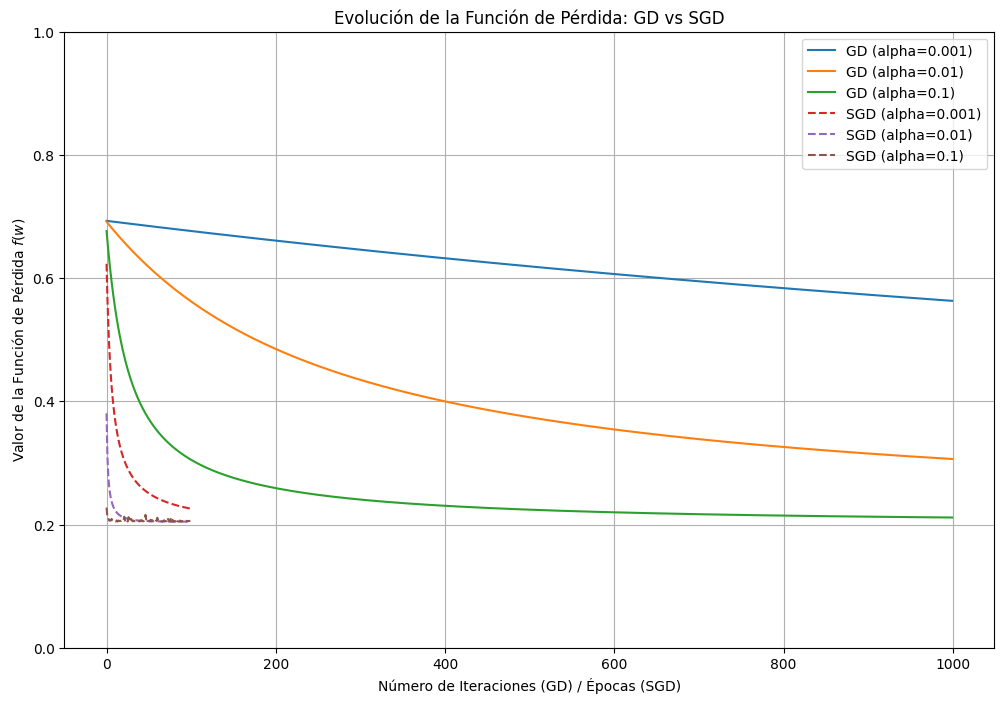

In [13]:
# Graficar la Evolución de la Función de Pérdida y Comparar la convergencia de GD y SGD para diferentes tasas de aprendizaje.

plt.figure(figsize=(12, 8))

# Graficar GD
for alpha, result in results_gd.items():
    plt.plot(result['loss_history'], label=f'GD (alpha={alpha})', linestyle='-')

# Graficar SGD
for alpha, result in results_sgd.items():
     plt.plot(result['loss_history'], label=f'SGD (alpha={alpha})', linestyle='--')


plt.xlabel('Número de Iteraciones (GD) / Épocas (SGD)')
plt.ylabel('Valor de la Función de Pérdida $f(w)$')
plt.title('Evolución de la Función de Pérdida: GD vs SGD')
plt.legend()
plt.grid(True)
plt.ylim(0, 1) # Ajustar límites si es necesario para mejor visualización
plt.show()

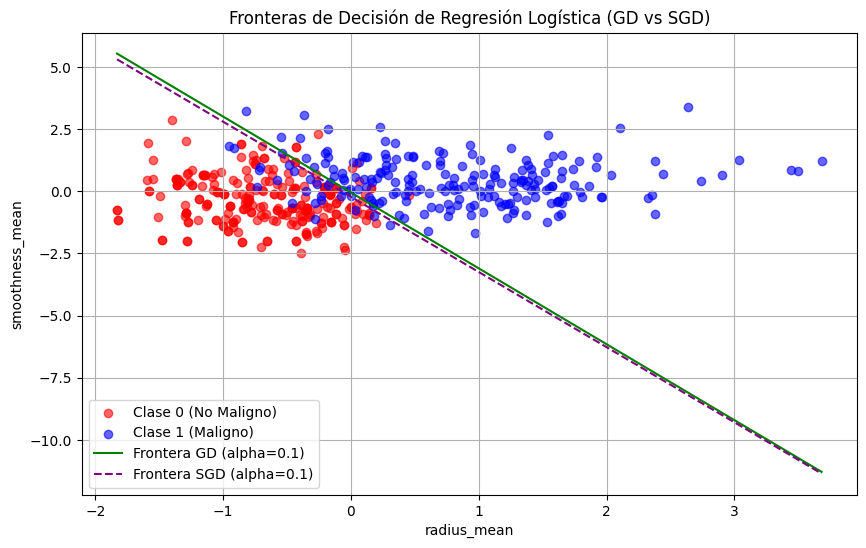

In [14]:
# Graficar las Rectas Separadoras

plt.figure(figsize=(10, 6))

# Scatter plot de los datos
plt.scatter(X[t == 0, 0], X[t == 0, 1], color='red', label='Clase 0 (No Maligno)', alpha=0.6)
plt.scatter(X[t == 1, 0], X[t == 1, 1], color='blue', label='Clase 1 (Maligno)', alpha=0.6)

# Graficar rectas separadoras para los resultados de GD (usando el último alpha probado)
if alphas_gd:
    optimal_w_gd = results_gd[alphas_gd[-1]]['w'] # Usar el último alpha de GD
    if optimal_w_gd[1] != 0:
        x1_values = np.array([X[:, 0].min(), X[:, 0].max()])
        x2_values_gd = (-optimal_w_gd[0] / optimal_w_gd[1]) * x1_values - (optimal_w_gd[2] / optimal_w_gd[1])
        plt.plot(x1_values, x2_values_gd, color='green', linestyle='-', label=f'Frontera GD (alpha={alphas_gd[-1]})')

# Graficar rectas separadoras para los resultados de SGD (usando el último alpha probado)
if alphas_sgd:
    optimal_w_sgd = results_sgd[alphas_sgd[-1]]['w'] # Usar el último alpha de SGD
    if optimal_w_sgd[1] != 0:
        x1_values = np.array([X[:, 0].min(), X[:, 0].max()])
        x2_values_sgd = (-optimal_w_sgd[0] / optimal_w_sgd[1]) * x1_values - (optimal_w_sgd[2] / optimal_w_sgd[1])
        plt.plot(x1_values, x2_values_sgd, color='purple', linestyle='--', label=f'Frontera SGD (alpha={alphas_sgd[-1]})')


plt.xlabel('radius_mean')
plt.ylabel('smoothness_mean')
plt.title('Fronteras de Decisión de Regresión Logística (GD vs SGD)')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de los resultados:

- La gráfica de la función de pérdida muestra cómo ambos algoritmos intentan minimizar el costo.
- GD generalmente tiene un descenso más suave y predecible si la tasa de aprendizaje es adecuada.
- SGD puede mostrar más ruido en su descenso debido a las actualizaciones basadas en ejemplos individuales, pero puede ser más rápido en conjuntos de datos grandes y puede escapar de mínimos locales (aunque la pérdida de regresión logística es convexa).
- La elección de la tasa de aprendizaje (alpha) es crucial para ambos algoritmos. Un alpha muy pequeño resulta en una convergencia lenta, mientras que un alpha muy grande puede causar oscilaciones o divergencia.
- Las fronteras de decisión finales representan el clasificador lineal aprendido por cada algoritmo.